# Sea-level response from ISMIP6 ice-sheet projections

This notebook extends the DTC-IS SLR framework to use **future ice-sheet projections** from the
[Ice Sheet Model Intercomparison Project for CMIP6 (ISMIP6)](https://www.climate-cryosphere.org/mips/ismip6)
as the mass balance input.

We here go from the native DTC-IS EO-data-driven approach to a purly modelling projection-framework

**Key features:**
- **Model selection:** Choose an ice-sheet model and forcing experiment via dropdown menus.
- **Projection period:** Specify the start and end years within the ISMIP6 projection window (typically 2015–2100).
- **Animation:** Visualise the spatial evolution of ice-sheet mass change over time.
- **Scenario exploration:** Apply custom scaling factors to simulate different "what-if" scenarios.
- **SLR calculation:** Feed the ISMIP6 mass balance data into the SELREM sea-level model for global and location-specific projections.

**How to use this notebook:**
1. Run the setup cells below.
2. Select an ice-sheet model and experiment, set the year range, then click **Load ISMIP6 Data**.
3. Generate the animation of cumulative ice-sheet mass change.
4. Adjust the scaling factor and explore sea-level responses globally and at chosen locations.

**Requirements:**
- Jupyter (or VS Code with the Jupyter extension).
- Internet access to the ISMIP6 object store and the DTC-IS API.

---

*ISMIP6 data are provided under their respective licences. See [ismip.org](https://www.ismip.org) for details.*

In [ ]:
import sys

print("⏳ Installing dependencies...")
if "google.colab" in sys.modules:
    %pip install -q xarray zarr cartopy fsspec aiohttp s3fs==2025.3.0 ipywidgets==7.7.1
    # Ensure the newest version of the helpers package is installed
    %pip uninstall -y dtc_is_notebooks
    %pip install -q --upgrade --force-reinstall --no-deps --no-cache-dir  git+https://github.com/DTC-Ice-Sheets/dtc_is_notebooks.git

## Notebook preparations

In [ ]:
%load_ext autoreload
%autoreload 2
import os
from datetime import datetime

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import ipywidgets as widgets
import matplotlib.animation as animation
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from IPython.display import HTML, clear_output
from IPython.display import display as ipydisplay
from matplotlib.widgets import Button
from pyproj import CRS, Transformer
from shapely.geometry import box

from dtc_is_notebook_helpers.api_helpers import (
    mass_balance_from_thickness,
    run_data_download,
    run_selrem_module,
)
from dtc_is_notebook_helpers.uc2_plotting_helpers import (
    MASS_BALANCE_COL_NAME,
    MASS_BALANCE_ERROR_COL_NAME,
    compute_mean_mass_balance_over_time_window,
    plot_global_slr_three_panels,
    plot_scaled_mean_mass_balance,
    plot_slr_location_four_panels,
)

os.environ["OMP_DISPLAY_ENV"] = "FALSE"
os.environ["KMP_WARNINGS"] = "FALSE"
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

api_token = input(
    "Please generate your own DTC-IS API token at https://query.dtc-ice-sheets.org/auth/get-token and paste it here: "
)
os.environ["DTC_API_TOKEN"] = api_token

## Select ISMIP6 model and experiment

Choose an **ice-sheet model** and a **forcing experiment** from the dropdowns below, then set
the projection years and click **Load ISMIP6 Data**.

| Experiment | Description |
|-----------|-------------|
| exp05 | High-emissions forcing (RCP 8.5) |
| exp07 | Low-emissions forcing (RCP 2.6) |
| ctrl_proj_std | Standard control projection |

> **Note:** Not all model–experiment combinations are available. If loading fails, try a different combination.

---

In [ ]:
model_options = [
    ("DOE / MALI", "DOE_MALI"),
    ("AWI / PISM1", "AWI_PISM1"),
    ("LSCE / GRISLI2", "LSCE_GRISLI2"),
    ("NCAR / CISM", "NCAR_CISM"),
    ("JPL / ISSM", "JPL1_ISSM"),
]

experiment_options = [
    ("exp05 - high emissions (RCP 8.5)", "EXP05"),
    ("exp07 - low emissions (RCP 2.6)", "EXP07"),
    ("ctrl_proj_std - control projection", "CTRL"),
]

model_dropdown = widgets.Dropdown(
    options=list(model_options),
    value="DOE_MALI",
    description="Ice sheet model:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="380px"),
)
experiment_dropdown = widgets.Dropdown(
    options=list(experiment_options),
    value="EXP05",
    description="Experiment:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="380px"),
)
start_year_widget = widgets.IntText(value=2015, description="Start year:", style={"description_width": "initial"})
end_year_widget = widgets.IntText(value=2100, description="End year:", style={"description_width": "initial"})

load_button = widgets.Button(description="Load ISMIP6 Data", button_style="success")
load_output = widgets.Output()
load_status = widgets.Label(value="")

# Module-level state shared with downstream cells
start_time = None
end_time = None
mb_annual = None
downloaded_ismip6_data_zarr_url = None
derived_mb_point_zarr_url = None


def on_load_clicked(b: Button) -> None:
    """Load ISMIP6 projection data and keep mass-balance data fully in memory."""
    global \
        mb_annual, \
        start_time, \
        end_time, \
        downloaded_ismip6_data_zarr_url, \
        derived_mb_point_zarr_url

    model = model_dropdown.value
    exp = experiment_dropdown.value
    start_yr = start_year_widget.value
    end_yr = end_year_widget.value

    if start_yr >= end_yr:
        load_status.value = "Error: Start year must be less than end year."
        return

    start_time = datetime(start_yr, 1, 1)
    end_time = datetime(end_yr, 12, 31)

    # mass_balance_from_thickness derives MB from a time-diff (thickness[t] - thickness[t-1]), so it
    # needs one extra baseline timestep before start_time to produce a value for start_yr itself.
    download_start_time = datetime(start_yr - 1, 1, 1)

    load_button.disabled = True
    load_status.value = f"⏳ Retrieving {model}/{exp} data..."

    with load_output:
        clear_output(wait=True)
        try:
            dataset_id = f"ISMIP6_{model}_{exp}"

            downloaded_ismip6_data_zarr_url = run_data_download(
                dataset_id, download_start_time, end_time, box(-180, -90, 180, -50), ["lithk", "sftgrf"]
            )
            load_status.value = f"⏳ Deriving mass balance from {model}/{exp} data..."

            derived_mb_point_zarr_url = mass_balance_from_thickness(
                downloaded_ismip6_data_zarr_url, prep_for_selrem=True, coarsen_factor=1
            )
            mass_balance_ds = xr.open_dataset(derived_mb_point_zarr_url, engine="zarr").compute()

            years = mass_balance_ds["time"].dt.year.values
            mb_matrix = mass_balance_ds[MASS_BALANCE_COL_NAME].values
            mean_mb_ds = compute_mean_mass_balance_over_time_window(mass_balance_ds, start_time, end_time)

            mean_annual_gt = float(mean_mb_ds[MASS_BALANCE_COL_NAME].sum()) / 1e12

            # ensure that years with all NaN values are treated as NaN in the total_mb_gt calculation
            all_nan_year = np.all(np.isnan(mb_matrix), axis=1)
            total_mb_gt = np.where(all_nan_year, np.nan, np.nansum(mb_matrix, axis=1) / 1e12)

            print(f"Model:       {model}")
            print(f"Experiment:  {exp}")
            print(f"Years:       {years[0]} – {years[-1]}")
            print(f"Grid cells:  {mass_balance_ds.sizes['point']}")
            print(f"Mean annual total MB: {mean_annual_gt:.2f} Gt/yr")
            print(
                f"Total MB range across years: {float(np.nanmin(total_mb_gt)):.2f} "
                f"to {float(np.nanmax(total_mb_gt)):.2f} Gt/yr"
            )

            load_status.value = f"Ready (in-memory): {model} / {exp}  ({start_yr}–{end_yr})"
            print("Mass-balance data kept in memory (no CSV upload).")

        except Exception as e:
            load_status.value = f"Error: {e}"
            print(f"Failed to load ISMIP6 data: {e}")
            raise

        load_button.disabled = False


load_button.on_click(on_load_clicked)

ipydisplay(
    model_dropdown,
    experiment_dropdown,
    start_year_widget,
    end_year_widget,
    load_button,
    load_status,
    load_output,
)

Dropdown(description='Ice sheet model:', layout=Layout(width='380px'), options=(('DOE / MALI', 'DOE_MALI'), ('…

Dropdown(description='Experiment:', layout=Layout(width='380px'), options=(('exp05 - high emissions (RCP 8.5)'…

IntText(value=2015, description='Start year:', style=DescriptionStyle(description_width='initial'))

IntText(value=2100, description='End year:', style=DescriptionStyle(description_width='initial'))

Button(button_style='success', description='Load ISMIP6 Data', style=ButtonStyle())

Label(value='')

Output()

## Animation: ice-sheet mass change through time

The animation below shows the **cumulative mass change** (Gt) at each grid cell, accumulated
year by year from the start of the selected projection period.

- **Blue** cells are gaining mass; **red** cells are losing mass.
- The colour scale is symmetric about zero and set from the 99th percentile of the data.
- Use the playback controls in the animation toolbar to pause, step, or scrub through time.

> Run the cell below **after** the data has loaded successfully in the cell above.

In [ ]:
load_status = widgets.Label(value="")
load_status.value = f"⏳ Deriving gridded mass balance from {model_dropdown.value}/{experiment_dropdown.value} data..."

derived_mb_grid_zarr_url = mass_balance_from_thickness(
                downloaded_ismip6_data_zarr_url, prep_for_selrem=False, coarsen_factor=1
            )
mb_annual = xr.open_dataset(derived_mb_grid_zarr_url, engine="zarr", decode_coords="all").compute()
_crs = CRS.from_user_input(mb_annual.rio.crs)
_epsg = _crs.to_epsg()
if _epsg == 3031:
    proj, region_label = ccrs.SouthPolarStereo(), "Antarctica"
elif _epsg == 3413:
    proj, region_label = ccrs.NorthPolarStereo(), "Greenland"
else:
    proj, region_label = ccrs.PlateCarree(), "Ice sheet"

cum_mb_gt = mb_annual[MASS_BALANCE_COL_NAME].cumsum("time") / 1e12

# Coarsen in native CRS (keeps cells compact and correctly shaped)
downsample = 4
frame_stride = 2
cum_mb_ds = cum_mb_gt.coarsen(y=downsample, x=downsample, boundary="trim").mean()

# Build 2D lon/lat for the coarsened native grid — required for correct cell shapes in polar plots
_x_2d, _y_2d = np.meshgrid(cum_mb_ds.x.values, cum_mb_ds.y.values)
_transformer = Transformer.from_crs(_crs, "EPSG:4326", always_xy=True)
lon_2d, lat_2d = _transformer.transform(_x_2d, _y_2d)

frame_indices = np.arange(0, cum_mb_ds.sizes["time"], frame_stride)
cum_mb_anim = cum_mb_ds.isel(time=frame_indices)
years_anim = cum_mb_anim["time"].dt.year.values
n_frames = len(years_anim)

all_vals = cum_mb_anim.values
vmax = float(np.nanpercentile(np.abs(all_vals), 99))
vmax = 1.0 if vmax == 0 else vmax
vmin = -vmax

model_label = model_dropdown.label
exp_label = experiment_dropdown.label

frame_data = np.asarray(cum_mb_anim.values)

fig = plt.figure(figsize=(8, 6), dpi=80)
ax = fig.add_subplot(1, 1, 1, projection=proj)
ax.coastlines(linewidth=0.4, color="black", zorder=3)
ax.add_feature(cfeature.LAND, facecolor="#e0e0e0", zorder=0)
ax.gridlines(draw_labels=False, linewidth=0.3, color="gray", linestyle="--")

mesh = ax.pcolormesh(
    lon_2d,
    lat_2d,
    frame_data[0],
    transform=ccrs.PlateCarree(),
    cmap="RdBu",
    vmin=vmin,
    vmax=vmax,
    shading="nearest",
    zorder=1,
)
title = ax.set_title(
    f"Cumulative mass change — {model_label}\n{exp_label}   |   {region_label}   |   Year {years_anim[0]}",
    fontsize=10,
)

cbar = fig.colorbar(mesh, ax=ax, orientation="vertical", fraction=0.04, pad=0.05)
cbar.set_label("Cumulative mass change (Gt/cell)", fontsize=9)


def _draw_frame(frame_idx: int) -> tuple:
    mesh.set_array(frame_data[frame_idx].ravel())
    title.set_text(
        f"Cumulative mass change — {model_label}\n{exp_label}   |   {region_label}   |   Year {years_anim[frame_idx]}"
    )
    return mesh, title


anim = animation.FuncAnimation(
    fig,
    _draw_frame,
    frames=n_frames,
    interval=100,
    blit=False,
    repeat=True,
)
plt.close(fig)

print(
    f"Rendering {n_frames}-frame cumulative mass change animation "
    f"(downsampled {downsample}x, every {frame_stride} yr, {years_anim[0]}–{years_anim[-1]})..."
)
ipydisplay(HTML(anim.to_jshtml()))

{'job_id': 'mass-balance-from-thickness-template-2p8hm'}


/tmp/ipykernel_1046457/885640235.py:8: UserWarning: Variable(s) referenced in bounds not in variables: ['time_bnds']
  mb_annual = xr.open_dataset(derived_mb_grid_zarr_url, engine="zarr", decode_coords="all").compute()


KeyboardInterrupt: 

## How does the projected mass input translate to sea-level change globally?

After importing, and optionally **scaling**, the projected **terrestrial mass contribution**
from the ISMIP6 ice-sheet model, we can now examine the **instantaneous Equivalent Sea Level (ESL)**.

- The **instantaneous global equivalent sea level response** is calculated based on your selected
  scaling factor and the ISMIP6 projection data.
- The **relative sea-level change** at each location accounts for local vertical deformation
  (e.g., glacial isostatic adjustment).
- **Rotational feedback** from the redistribution of water mass is included.
- The **uncertainty** reflects the SELREM model uncertainty but does **not** include the
  ice-sheet model or forcing uncertainty from ISMIP6.

---

{'job_id': 'mass-balance-from-thickness-template-mrvcr'}


/home/bizonjulia/.conda/envs/dtc/lib/python3.12/site-packages/matplotlib/cbook.py:1810: UserWarning: Warning: converting a masked element to nan.
  return math.isfinite(val)


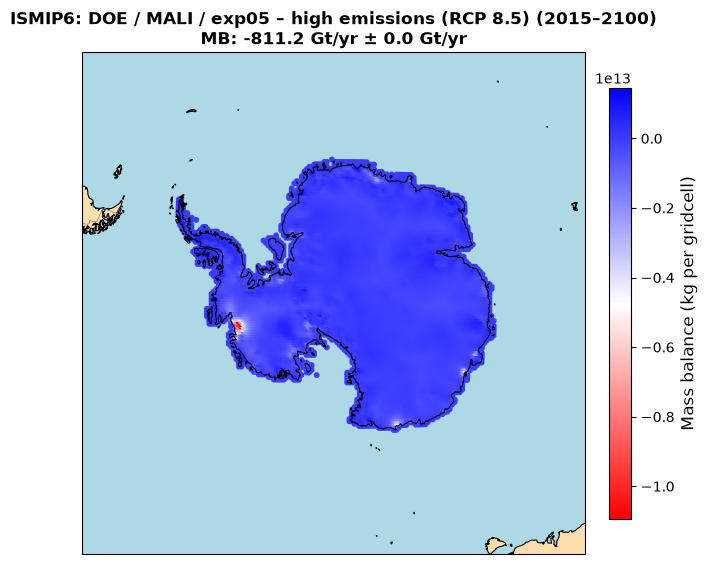

Label(value='')

{'job_id': 'use-case-2-selrem-z7g7t'}


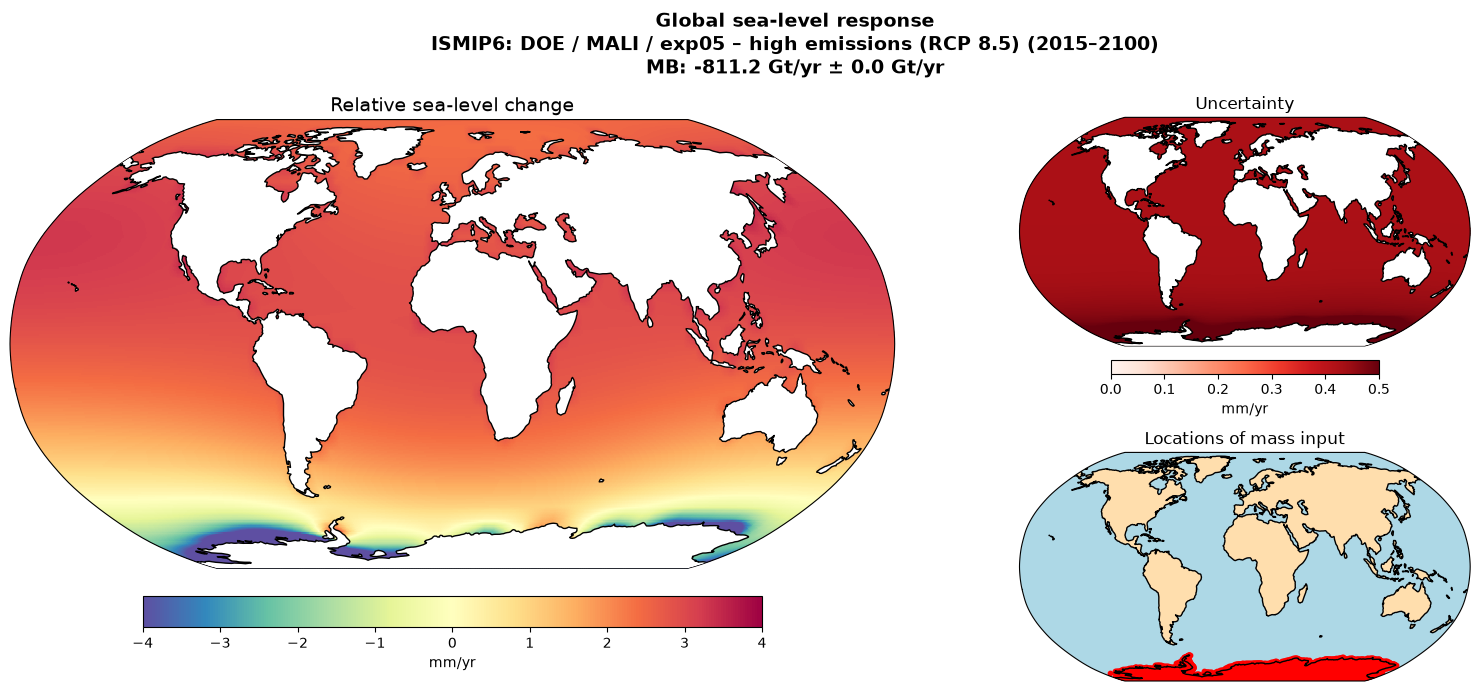

In [ ]:

if downloaded_ismip6_data_zarr_url is None:
    print("Please load ISMIP6 data first using the cell above.")
else:
    selrem_scale = 1.0
    _proj_label = f"{model_dropdown.label} / {experiment_dropdown.label}"
    derived_mb_point_coarsened_zarr_url = mass_balance_from_thickness(
        downloaded_ismip6_data_zarr_url, prep_for_selrem=True, coarsen_factor=5
    )
    mass_balance_ds_coarsened = xr.open_dataset(derived_mb_point_coarsened_zarr_url, engine="zarr")

    mean_mb_coarsened_ds = compute_mean_mass_balance_over_time_window(mass_balance_ds_coarsened, start_time, end_time)

    total_mb_gt = float(mean_mb_coarsened_ds[MASS_BALANCE_COL_NAME].sum()) / 1e12
    total_mb_err_gt = float(mean_mb_coarsened_ds[MASS_BALANCE_ERROR_COL_NAME].sum(skipna=True)) / 1e12
    mb_str = f"MB: {total_mb_gt:.1f} Gt/yr ± {total_mb_err_gt:.1f} Gt/yr"

    lat_vals = mean_mb_coarsened_ds["y"].values
    valid_lat_vals = lat_vals[~np.isnan(lat_vals)]
    if np.any(valid_lat_vals < 0) and np.any(valid_lat_vals > 0):
        plot_dataset_value = "AIS and GrIS"
    elif np.any(valid_lat_vals < 0):
        plot_dataset_value = "AIS"
    elif np.any(valid_lat_vals > 0):
        plot_dataset_value = "GrIS"
    else:
        plot_dataset_value = "custom"

    plot_scaled_mean_mass_balance(
        mean_mb_coarsened_ds,
        dataset_value=plot_dataset_value,
        plot_description_str=f"ISMIP6: {_proj_label} ({start_time.year}–{end_time.year})\n{mb_str}",
        scale=selrem_scale,
    )

    status_label = widgets.Label(value="")
    ipydisplay(status_label)

    suptitle = f"Global sea-level response\nISMIP6: {_proj_label} ({start_time.year}-{end_time.year})\n{mb_str}"

    status_label.value = "⏳ Running SELREM module (this may take a few minutes)..."
    global_slr_ds = run_selrem_module(derived_mb_point_coarsened_zarr_url, selrem_scale, start_time.year, end_time.year, "global")
    status_label.value = "⏳ Downloading SELREM output..."
    global_slr_ds = global_slr_ds.compute()
    status_label.value = "⏳ Generating plot..."
    plot_global_slr_three_panels(
        global_slr_ds,
        mean_mb_coarsened_ds,
        plot_description_str=suptitle,
    )
    status_label.value = ""

## Explore the sea-level response at a chosen location

Enter coordinates to investigate the projected sea-level change at any location on the globe.

- **Specify coordinates:** Enter latitude and longitude.
- **Adjust scenario:** Modify the scaling factor to explore amplified/dampened projections.
- **Visualise:** Click **Plot SLR at location** to see the annual time series.

Note that changing the scaling factor requires re-running the SELREM module, which may take
a few minutes.

In [ ]:
lat_input = widgets.FloatText(value=55.7, description="Latitude:", step=0.1)
lon_input = widgets.FloatText(value=12.6, description="Longitude:", step=0.1)
scale_loc_input = widgets.FloatText(value=1.0, description="Scaler:", step=0.01)
plot_button = widgets.Button(description="Plot SLR at location", button_style="success")
note_label = widgets.Label(
    value="Note: When changing the scaling factor, plotting may take a few minutes to recalculate."
)
status_label = widgets.Label(value="")
slr_plot_output = widgets.Output()


def _on_plot_button_clicked(b: Button) -> None:
    lat0 = lat_input.value
    lon0 = lon_input.value
    with slr_plot_output:
        clear_output(wait=True)
        status_label.value = "⏳ Generating plot..."
        plot_button.disabled = True
        plot_slr_location_four_panels(annual_slr_ds, lat0=lat0, lon0=lon0)
        status_label.value = ""
        plot_button.disabled = False


plot_button.on_click(_on_plot_button_clicked)


def _on_scale_loc_change(change: dict) -> None:
    global annual_slr_ds
    status_label.value = "⏳ Running SELREM module (this may take a few minutes)..."
    plot_button.disabled = True
    annual_slr_ds = run_selrem_module(derived_mb_point_coarsened_zarr_url,
                                      scale_loc_input.value,
                                      start_time.year,
                                      end_time.year,
                                      "annual")
    status_label.value = "⏳ Downloading SELREM output..."
    annual_slr_ds = annual_slr_ds.compute()
    status_label.value = ""
    plot_button.disabled = False


scale_loc_input.observe(_on_scale_loc_change, names="value")
plot_button.disabled = True
ipydisplay(note_label, lat_input, lon_input, scale_loc_input, plot_button, status_label, slr_plot_output)

if derived_mb_point_coarsened_zarr_url is None:
    print("Coarsened mass balance data not generated yet, please ensure you load ISMIP6 data and run cell above.")
else:
    status_label.value = "⏳ Running SELREM module (this may take a few minutes)..."
    annual_slr_ds = run_selrem_module(
        derived_mb_point_coarsened_zarr_url, 1.0, start_time.year, end_time.year, "annual"
    )
    status_label.value = "⏳ Downloading SELREM output..."
    annual_slr_ds = annual_slr_ds.compute()
    status_label.value = ""
    plot_button.disabled = False

Label(value='Note: When changing the scaling factor, plotting may take a few minutes to recalculate.')

FloatText(value=55.7, description='Latitude:', step=0.1)

FloatText(value=12.6, description='Longitude:', step=0.1)

FloatText(value=1.0, description='Scaler:', step=0.01)

Button(button_style='success', description='Plot SLR at location', disabled=True, style=ButtonStyle())

Label(value='')

Output()

{'job_id': 'use-case-2-selrem-6brm7'}
